In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    r"C:\data\complaints.csv",
    dtype=str
)

print(df.columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [3]:
# Basic inspection
print(df.shape)
print(df.columns)
print(df.info())
df.head()

(9609797, 18)
Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags   

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 9,609,797
Columns: 18


In [5]:
from collections import Counter

product_counter = Counter()

for chunk in pd.read_csv(
    r"C:\data\complaints.csv",
    chunksize=100000,
    dtype=str,
    usecols=["Product"],
    on_bad_lines="skip"
):
    product_counter.update(chunk["Product"].dropna())

product_counts = pd.Series(product_counter).sort_values(ascending=False)
product_counts.head(15)

Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease           

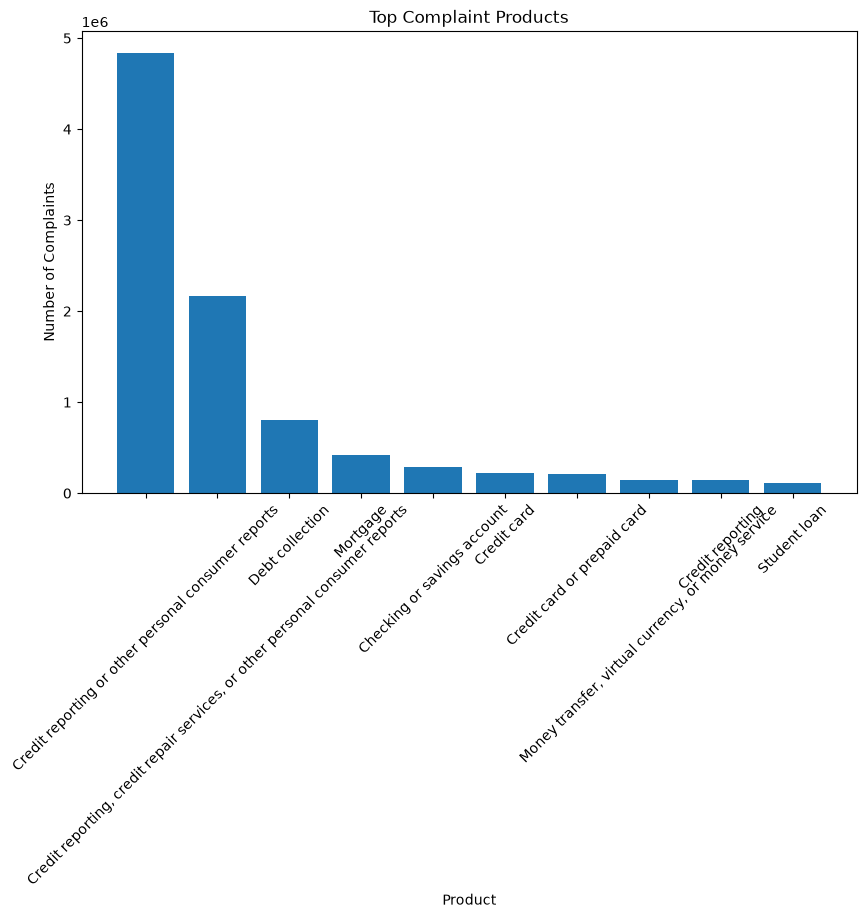

In [8]:
import matplotlib.pyplot as plt

top = product_counts.head(10)

plt.figure(figsize=(10,6))
plt.bar(top.index, top.values)

plt.title("Top Complaint Products")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

In [6]:
word_counts = []

for chunk in pd.read_csv(
    r"C:\data\complaints.csv",
    chunksize=50000,
    dtype=str,
    usecols=["Consumer complaint narrative"],
    on_bad_lines="skip"
):
    texts = chunk["Consumer complaint narrative"].fillna("").astype(str)
    word_counts.extend(texts.str.split().str.len().tolist())

wc = pd.Series(word_counts)

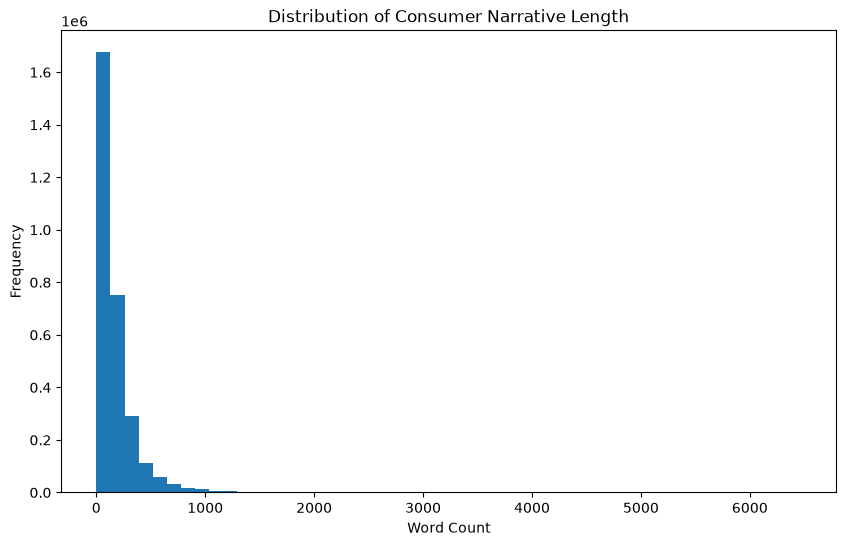

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(wc[wc > 0], bins=50)

plt.title("Distribution of Consumer Narrative Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [7]:
with_narrative = 0
without_narrative = 0

for chunk in pd.read_csv(
    r"C:\data\complaints.csv",
    chunksize=100000,
    dtype=str,
    usecols=["Consumer complaint narrative"],
    on_bad_lines="skip"
):
    narr = chunk["Consumer complaint narrative"]

    with_narrative += narr.notna().sum()
    without_narrative += narr.isna().sum()

with_narrative, without_narrative

(np.int64(2980756), np.int64(6629041))

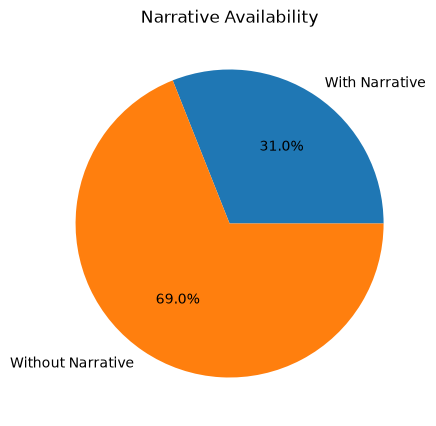

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.pie(
    [with_narrative, without_narrative],
    labels=["With Narrative", "Without Narrative"],
    autopct="%1.1f%%"
)

plt.title("Narrative Availability")
plt.show()

In [8]:
df["Product"].value_counts().head(30)

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

In [9]:
target_products = [
    "credit card",
    "personal loan",
    "savings account",
    "money transfer"
]

In [10]:
import pandas as pd

output_file = r"C:\data\filtered_complaints.csv"
first_write = True

for chunk in pd.read_csv(
    r"C:\data\complaints.csv",
    chunksize=100000,
    dtype=str,
    on_bad_lines="skip"
):
    # normalize
    chunk["Product_lower"] = chunk["Product"].str.lower()

    # filter products using substring match
    filtered = chunk[
        chunk["Product_lower"].str.contains("credit card", na=False) |
        chunk["Product_lower"].str.contains("personal loan", na=False) |
        chunk["Product_lower"].str.contains("savings account", na=False) |
        chunk["Product_lower"].str.contains("money transfer", na=False)
    ]

    # remove missing narratives
    filtered = filtered[
        filtered["Consumer complaint narrative"].notna() &
        (filtered["Consumer complaint narrative"].str.strip() != "")
    ]

    # drop helper column
    filtered = filtered.drop(columns=["Product_lower"])

    # write incrementally
    filtered.to_csv(
        output_file,
        mode="w" if first_write else "a",
        index=False,
        header=first_write
    )

    first_write = False

In [11]:
df_f = pd.read_csv(r"C:\data\filtered_complaints.csv")

print(df_f.shape)
df_f["Product"].value_counts()

(454472, 18)


Product
Checking or savings account                                140319
Credit card or prepaid card                                108667
Money transfer, virtual currency, or money service          97188
Credit card                                                 80667
Payday loan, title loan, or personal loan                   17238
Payday loan, title loan, personal loan, or advance loan      8896
Money transfers                                              1497
Name: count, dtype: int64

In [12]:
import re

BOILERPLATE_PATTERNS = [
    r"i am writing to (file|submit|make) (a )?complaint",
    r"this is a complaint regarding",
    r"i would like to (report|complain about)",
    r"i am contacting you to",
]

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # remove boilerplate phrases
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, "", text)

    # remove special characters (keep letters, numbers, spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [13]:
import pandas as pd

input_file = r"C:\data\filtered_complaints.csv"
output_file = r"C:\data\cleaned_complaints.csv"

first_write = True

for chunk in pd.read_csv(input_file, chunksize=100000, dtype=str):

    chunk["clean_narrative"] = chunk["Consumer complaint narrative"].apply(clean_text)

    # remove empty after cleaning
    chunk = chunk[chunk["clean_narrative"].str.strip() != ""]

    chunk.to_csv(
        output_file,
        mode="w" if first_write else "a",
        index=False,
        header=first_write
    )

    first_write = False

In [21]:
print(df.columns)

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')


In [14]:
# This will execute in seconds, even on 9.6 million rows
df["word_count"] = [len(str(text).split()) if text else 0 for text in df["Consumer complaint narrative"]]

In [15]:
print("word_count" in df.columns)

True


In [16]:
short_narratives = df[
    (df['word_count'] > 0) &
    (df['word_count'] < 20)
]


print("Very short narratives:", len(short_narratives))

Very short narratives: 6753289


In [18]:
long_narratives = df[
    df['word_count'] > 1000
]

print("Very long narratives:", len(long_narratives))

Very long narratives: 32428


In [ ]:
df_clean